In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve
import seaborn as sns

In [6]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [8]:
df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [12]:
x = df.iloc[:,[2,3]].values.astype("float32")
y = df.iloc[:,4].values.astype("float32")

x.shape, y.shape

((400, 2), (400,))

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((320, 2), (80, 2), (320,), (80,))

In [16]:
sc = StandardScaler()
x_train=sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [18]:
x_train.shape, x_test.shape

((320, 2), (80, 2))

In [20]:
LogisticRegression?

Init signature:
LogisticRegression(
    penalty='l2',
    *,
    dual=False,
    tol=0.0001,
    C=1.0,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    multi_class='deprecated',
    verbose=0,
    warm_start=False,
    n_jobs=None,
    l1_ratio=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

In the multiclass case, the training algorithm uses the one-vs-rest (OvR)
scheme if the 'multi_class' option is set to 'ovr', and uses the
cross-entropy loss if the 'multi_class' option is set to 'multinomial'.
(Currently the 'multinomial' option is supported only by the 'lbfgs',
'sag', 'saga' and 'newton-cg' solvers.)

This class implements regularized logistic regression using the
'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
that regularization is applied by default**. It can handle both dense
and sparse input. Use C-ordered arrays or CSR matrices co

In [24]:
lr_clf = LogisticRegression()
lr_clf.fit(x_train,y_train)

LogisticRegression()

In [28]:
y_pred = lr_clf.predict(x_test)
y_pred

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1.], dtype=float32)

In [30]:
accuracy_score(y_test, y_pred)

0.925

In [32]:
precision_score(y_test, y_pred)

0.9444444444444444

In [48]:
recall_score(y_test, y_pred)

0.7727272727272727

In [56]:
threshold = 0.3

In [60]:
y_pred_proba = lr_clf.predict_proba(x_test)
y_pred_proba1 = y_pred_proba[:,1]> threshold
y_pred_proba1

array([False, False, False, False, False, False, False,  True, False,
        True, False, False, False,  True, False,  True, False, False,
        True, False, False,  True, False,  True, False,  True, False,
       False, False, False, False,  True,  True, False, False, False,
       False, False, False,  True, False, False, False, False,  True,
       False,  True,  True, False,  True,  True, False, False,  True,
        True,  True, False, False,  True, False, False,  True, False,
        True, False,  True, False, False, False,  True,  True, False,
       False, False, False, False,  True,  True,  True,  True])

In [62]:
sum((y_pred_proba[:,1]> 0.5) == y_test) /len(y_test)

0.925

In [68]:
recall_score(y_test, y_pred_proba1)

0.9545454545454546

In [76]:
cm = confusion_matrix(y_test, y_pred, labels=[1,0])
cm

array([[17,  5],
       [ 1, 57]], dtype=int64)

Text(0.5, 23.52222222222222, 'True')

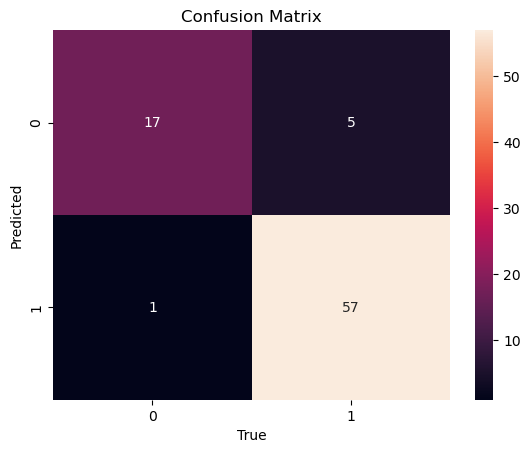

In [80]:
ax = sns.heatmap(cm, annot=True, fmt='d')
ax.set_title('Confusion Matrix')
ax.set_ylabel('Predicted')
ax.set_xlabel('True')

In [100]:
y_proba= lr_clf.predict_proba(x_test)
y_score= y_proba[:,1]
fpr,tpr,_ = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

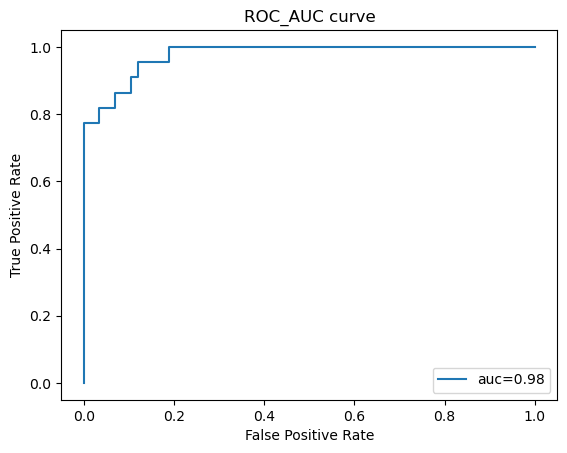

In [104]:
plt.plot(fpr, tpr, label="auc={:.2f}".format(auc))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC_AUC curve')
plt.legend()

In [110]:
y_proba = lr_clf.predict_proba(x_test)
y_score = y_proba[:,1]
fpr,tpr,_=roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

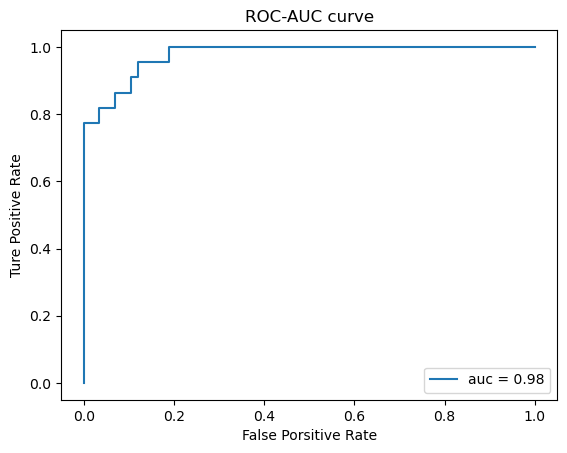

In [114]:
plt.plot(fpr, tpr, label="auc = {:.2f}".format(auc))

plt.xlabel("False Porsitive Rate")
plt.ylabel("Ture Positive Rate")
plt.title("ROC-AUC curve")
plt.legend()